In [1]:
# These modules are required for working with the data.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

16:08:28.802 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdfits = GBTFITSLoad(filename)

16:08:28.908 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


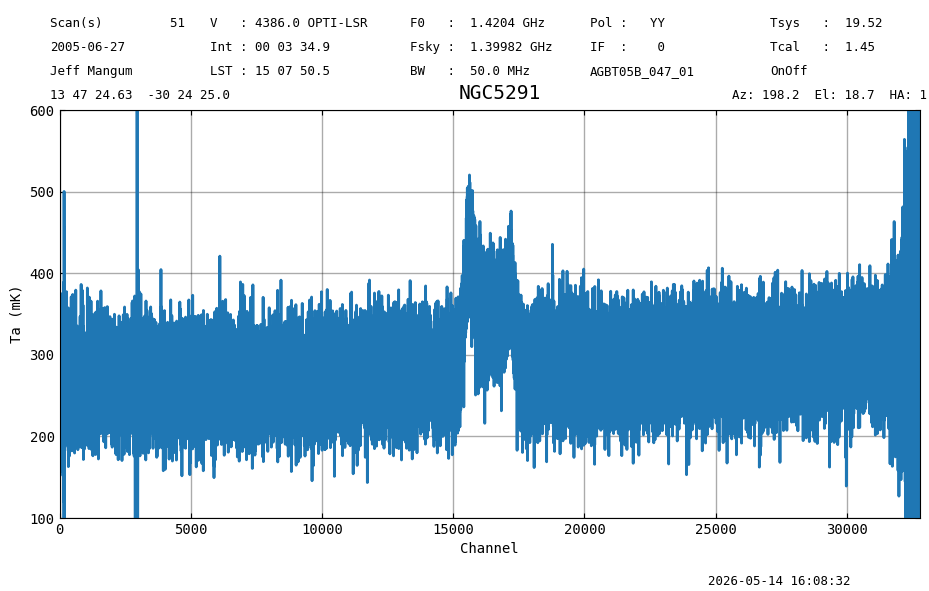

Stats : mean: 0.2708 K median: 0.2711 K rms: 0.0359 K min: 0.14 K max: 0.42 K
Expect: mean: 0.2708 K median: 0.2711 K rms: 0.0359 K min: 0.14 K max: 0.42 K
Stats : mean: 0.2916 K median: 0.2916 K rms: 0.0366 K min: 0.14 K max: 0.41 K
Expect: mean: 0.2916 K median: 0.2916 K rms: 0.0366 K min: 0.14 K max: 0.41 K


In [6]:
scan_block = sdfits.getps(ifnum=0, plnum=0, fdnum=0)
ta = scan_block.timeaverage()
ta.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=100, ymax=600, grid=True)

# Define a string for printing the spectrum statistics.
fmt_str = "mean: {mean:.4f} median: {median:.4f} rms: {rms:.4f} min: {min:.2f} max: {max:.2f}"
print(f"Stats : {fmt_str}".format(**ta[5000:14000].stats()))
print("Expect: mean: 0.2708 K median: 0.2711 K rms: 0.0359 K min: 0.14 K max: 0.42 K")
print(f"Stats : {fmt_str}".format(**ta[20000:30000].stats()))
print("Expect: mean: 0.2916 K median: 0.2916 K rms: 0.0366 K min: 0.14 K max: 0.41 K")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


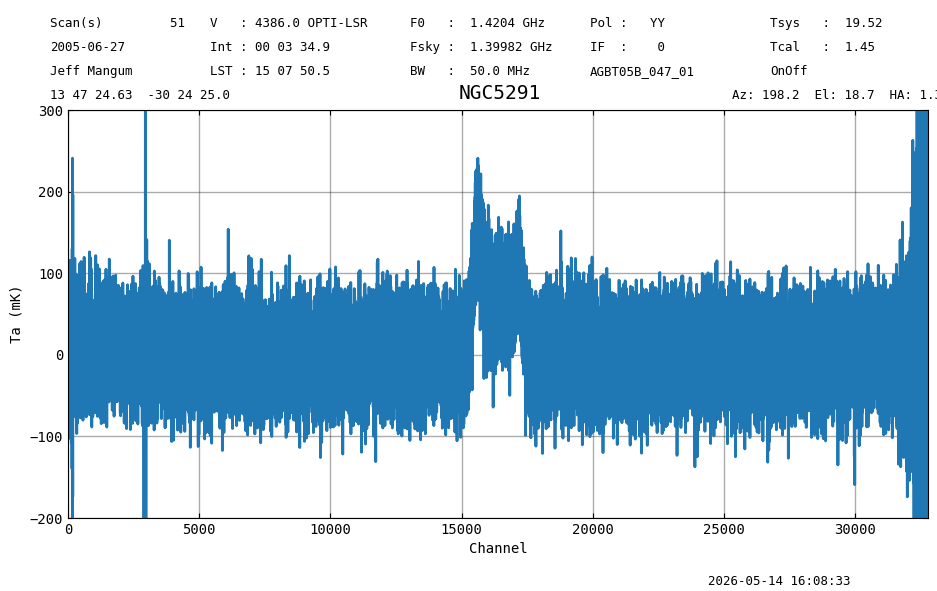

Stats : mean: -0.0007 K median: -0.0007 K rms: 0.0358 K min: -0.13 K max: 0.15 K
Expect: mean: -0.0007 K median: -0.0007 K rms: 0.0358 K min: -0.13 K max: 0.15 K


In [7]:
ta.baseline(model="poly", degree=1, include=[[3500,14000],[18000,30000]], remove=True)
ta.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=-200, ymax=300, grid=True)
print(f"Stats : {fmt_str}".format(**ta[5000:14000].stats()))
print("Expect: mean: -0.0007 K median: -0.0007 K rms: 0.0358 K min: -0.13 K max: 0.15 K")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


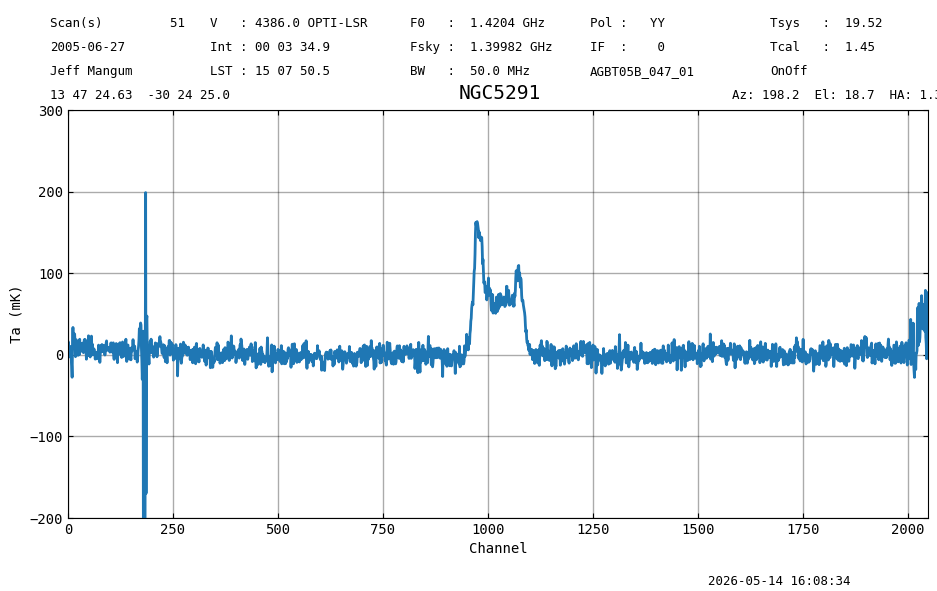

Stats : mean: -0.0007 K median: -0.0007 K rms: 0.0075 K min: -0.02 K max: 0.02 K
Expect: mean: 0.0005 K median: 0.0004 K rms: 0.0075 K min: -0.02 K max: 0.03 K


In [8]:
ts1 = ta.smooth('gaussian', 16)
ts1.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=-200, ymax=300, grid=True)
print(f"Stats : {fmt_str}".format(**ts1[5000//16:14000//16].stats()))
print("Expect: mean: 0.0005 K median: 0.0004 K rms: 0.0075 K min: -0.02 K max: 0.03 K")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


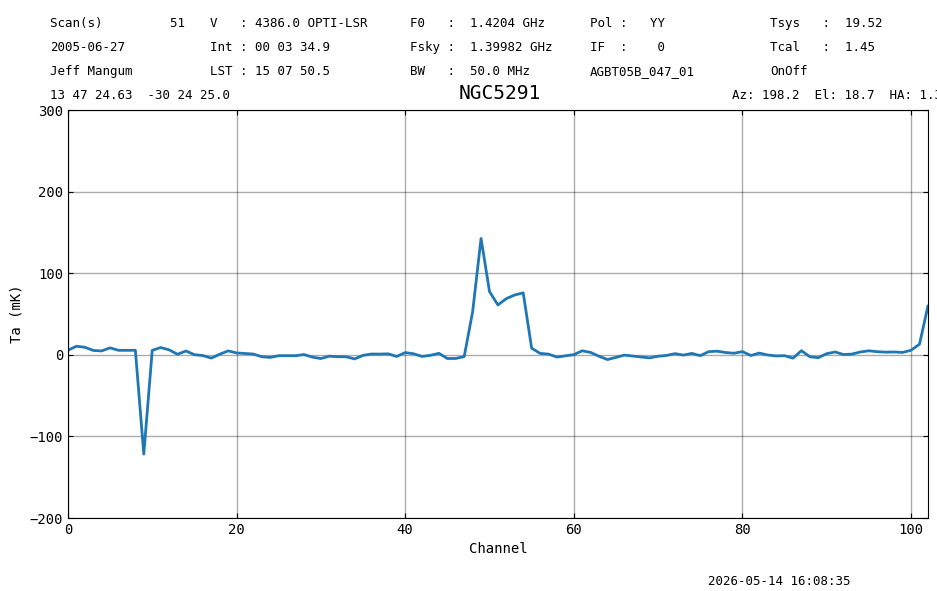

Stats : mean: -0.0007 K median: -0.0010 K rms: 0.0023 K min: -0.01 K max: 0.00 K


Rolled rms/rms ratio: 0.7845596461442605


In [9]:
ts2 = ta.smooth('box', 320)
ts2.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=-200, ymax=300, grid=True)

print(f"Stats : {fmt_str}".format(**ts2[5000//320:14000//320].stats()))
rratio = ts2[5000//320:14000//320].stats(roll=1)["rms"]/ts2[5000//320:14000//320].stats(roll=0)["rms"]
print(f"Rolled rms/rms ratio: {rratio}")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


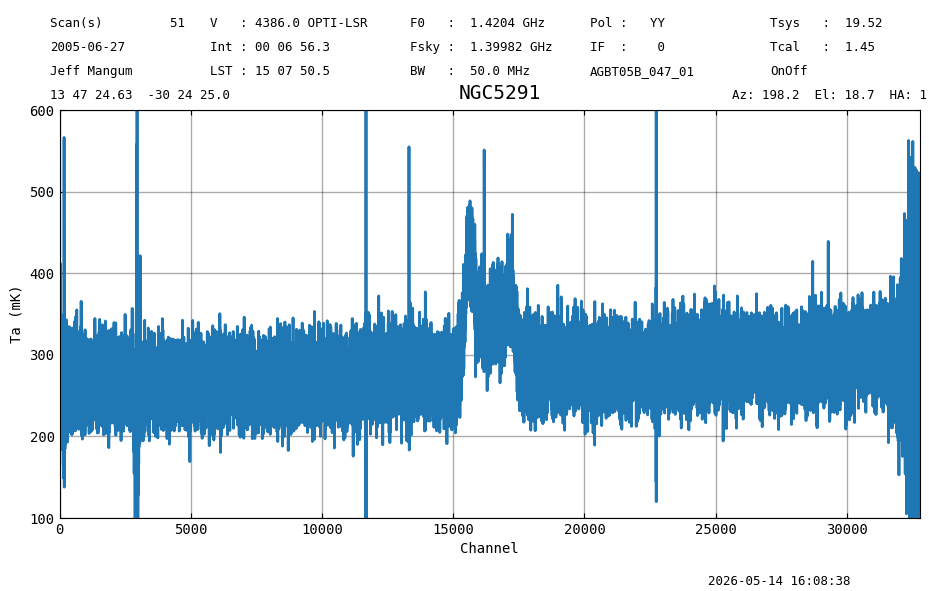

Stats : mean: 0.2667 K median: 0.2666 K rms: 0.0254 K min: 0.18 K max: 0.35 K
Expect: mean: 0.2667 K median: 0.2666 K rms: 0.02536 K min: 0.18 K max: 0.35 K


In [10]:
scan_block2 = sdfits.getps(ifnum=0, plnum=0, fdnum=0, smoothref=31)
ta2 = scan_block2.timeaverage()
ta2.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=100, ymax=600, grid=True)
print(f"Stats : {fmt_str}".format(**ta2[5000:10000].stats()))   # avoid spikes
print("Expect: mean: 0.2667 K median: 0.2666 K rms: 0.02536 K min: 0.18 K max: 0.35 K")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


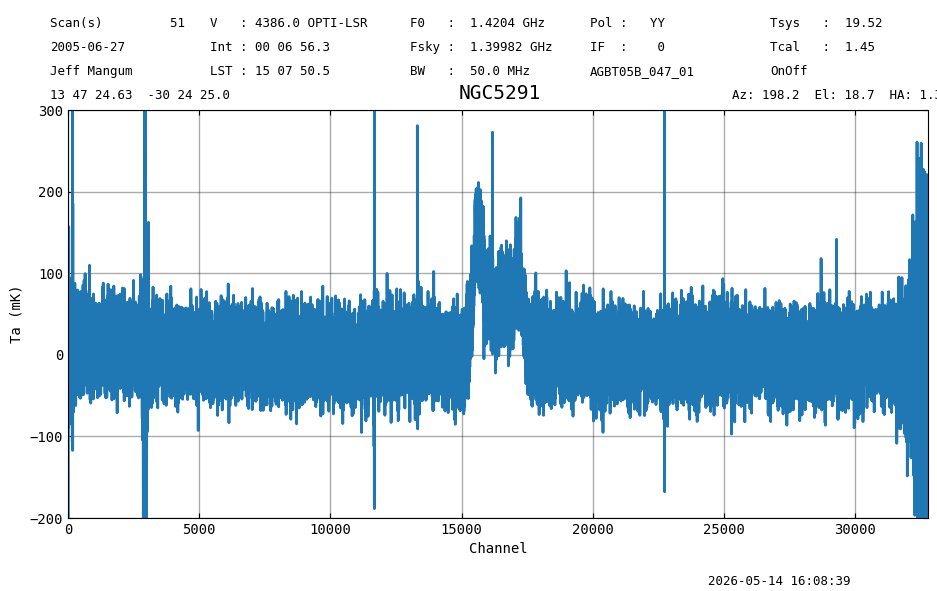

Stats : mean: 0.0009 K median: 0.0007 K rms: 0.0270 K min: -0.19 K max: 0.50 K
Expect: mean: 0.0009 K median: 0.0007 K rms: 0.0270 K min: -0.19 K max: 0.50 K


In [11]:
ta2.baseline(model="poly", degree=1, exclude=[(14000,18000)], remove=True)
ta2.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=-200, ymax=300, grid=True)
print(f"Stats : {fmt_str}".format(**ta2[5000:14000].stats()))
print("Expect: mean: 0.0009 K median: 0.0007 K rms: 0.0270 K min: -0.19 K max: 0.50 K")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


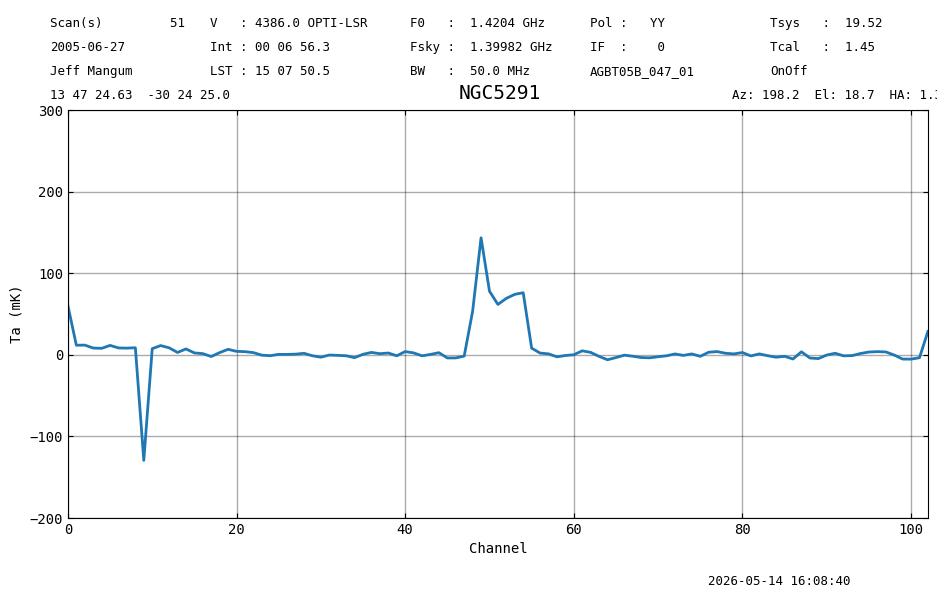

Stats : mean: 0.0009 K median: 0.0007 K rms: 0.0023 K min: -0.00 K max: 0.01 K


Rolled rms/rms ratio: 0.7802633164999715


In [12]:
ts3 = ta2.smooth('box', 320)
ts3.plot(xaxis_unit="chan", yaxis_unit="mK", ymin=-200, ymax=300, grid=True)
print(f"Stats : {fmt_str}".format(**ts3[5000//320:14000//320].stats()))
rratio = ts3[5000//320:14000//320].stats(roll=1)["rms"]/ts3[5000//320:14000//320].stats(roll=0)["rms"]
print(f"Rolled rms/rms ratio: {rratio}")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


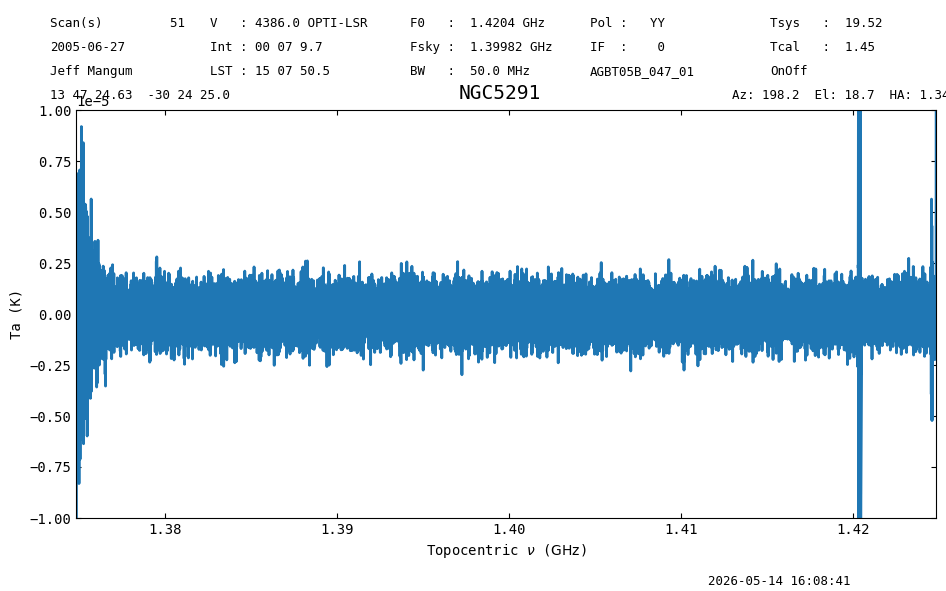

Stats : mean: -2.945e-10 K median: 4.285e-09 K rms: 7.291e-07 K min: -2.8e-06 K max: 2.7e-06 K


In [13]:
ts5a = ta.smooth('gaussian', width=3, decimate=-1).smooth('gaussian', width=5, decimate=-1)
ts5b = ta.smooth('gaussian', width=5, decimate=-1)
diff = ts5a-ts5b
diff.plot(ymin=-0.00001, ymax=0.00001)

fmt_str = "mean: {mean:.4g} median: {median:.4g} rms: {rms:.4g} min: {min:.2g} max: {max:.2g}"
print(f"Stats : {fmt_str}".format(**diff[5000:14000].stats()))

In [14]:
ts5b.check_stats(0.04618235 * u.K)

16:08:42.728 I rms is OK 
